In [69]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn

from wordle_env import load_wordle_environment
from wordle_networks import WordleDiscretePolicy
from es_wordle import train_es_wordle

In [70]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [71]:
env = load_wordle_environment(
    num_train_examples=1000,
    num_eval_examples=200,
    use_prime_intellect=False,
)

print(f"Environment loaded. max_turns={env.max_turns}, episodes={env.num_episodes}")

[OK] Mock Wordle environment (Prime Intellect disabled; targets from MOCK_WORDLE_TARGETS).
Environment loaded. max_turns=6, episodes=1000


In [72]:
STATE_DIM = 64
HIDDEN_DIM = 128
N_LAYERS = 3

def make_policy():
    return WordleDiscretePolicy(
        state_dim=STATE_DIM,
        hidden_dim=HIDDEN_DIM,
        n_layers=N_LAYERS,
    ).to(device)

In [73]:
def clone_policy(policy: nn.Module) -> nn.Module:
    return copy.deepcopy(policy)

def get_param_vector(policy: nn.Module) -> torch.Tensor:
    return torch.cat([p.data.view(-1).detach().cpu() for p in policy.parameters()])

def set_param_vector(policy: nn.Module, vec: torch.Tensor) -> None:
    vec = vec.to(next(policy.parameters()).device)
    idx = 0
    for p in policy.parameters():
        n = p.numel()
        p.data.copy_(vec[idx:idx+n].view_as(p))
        idx += n

def count_params(policy: nn.Module) -> int:
    return sum(p.numel() for p in policy.parameters())

In [74]:
import re

def extract_guess_from_xml(action_xml: str) -> str:
    match = re.search(r'<guess>(.*?)</guess>', action_xml)
    return match.group(1).strip() if match else "?????"

def play_one_game(policy, env, deterministic=True, verbose=False):
    state = env.reset()
    done = False
    turns = 0
    total_reward = 0.0
    guesses = []

    policy.eval()
    with torch.no_grad():
        while not done and turns < env.max_turns:
            state_embedding = env.get_state_embedding(state)
            action_xml, _ = policy.format_action_xml(
                state,
                state_embedding,
                deterministic=deterministic
            )

            guess = extract_guess_from_xml(action_xml)
            guesses.append(guess)

            state, reward, done, info = env.step(action_xml)
            total_reward += float(reward)
            turns += 1

            if verbose:
                print(f"Turn {turns}: {guess} | reward={reward:.3f}")
                if "feedback" in info:
                    print("  feedback:", info["feedback"])

    success = float(info.get("correct_answer", 0.0)) > 0.5
    return {
        "success": success,
        "turns": turns,
        "reward": total_reward,
        "guesses": guesses,
        "target": getattr(state, "target_word", None),
    }

def evaluate_policy_fixed(policy, env, n_episodes=50, deterministic=True):
    results = [play_one_game(policy, env, deterministic=deterministic, verbose=False)
               for _ in range(n_episodes)]

    success_rate = np.mean([r["success"] for r in results])
    avg_reward = np.mean([r["reward"] for r in results])
    avg_turns = np.mean([r["turns"] for r in results])

    solved_turns = [r["turns"] for r in results if r["success"]]
    avg_turns_success_only = np.mean(solved_turns) if solved_turns else float("nan")

    return {
        "success_rate": float(success_rate),
        "avg_reward": float(avg_reward),
        "avg_turns": float(avg_turns),
        "avg_turns_success_only": float(avg_turns_success_only) if solved_turns else float("nan"),
        "n_episodes": n_episodes,
        "raw": results,
    }

In [75]:
def train_randopt_wordle(
    base_policy,
    env,
    N=300,
    sigma=0.01,
    n_eval_episodes=10,
    score_key="avg_reward",
    verbose=True,
):
    best_policy = clone_policy(base_policy)
    best_vec = get_param_vector(best_policy)

    best_metrics = evaluate_policy_fixed(best_policy, env, n_episodes=n_eval_episodes)
    best_score = best_metrics[score_key]

    history = [{
        "step": 0,
        "best_score": best_score,
        "success_rate": best_metrics["success_rate"],
        "avg_reward": best_metrics["avg_reward"],
        "avg_turns": best_metrics["avg_turns"],
    }]

    if verbose:
        print(f"[RandOpt] step 0/{N} | "
              f"score={best_score:.4f} | "
              f"success={best_metrics['success_rate']:.3f} | "
              f"reward={best_metrics['avg_reward']:.3f}")

    for i in range(1, N + 1):
        candidate = clone_policy(base_policy)
        noise = torch.randn_like(best_vec) * sigma
        cand_vec = best_vec + noise
        set_param_vector(candidate, cand_vec)

        metrics = evaluate_policy_fixed(candidate, env, n_episodes=n_eval_episodes)
        score = metrics[score_key]

        if score > best_score:
            best_score = score
            best_vec = cand_vec.clone()
            best_policy = candidate
            best_metrics = metrics

        history.append({
            "step": i,
            "best_score": best_score,
            "success_rate": best_metrics["success_rate"],
            "avg_reward": best_metrics["avg_reward"],
            "avg_turns": best_metrics["avg_turns"],
        })

        if verbose and (i % max(1, N // 10) == 0 or i == N):
            print(f"[RandOpt] step {i}/{N} | "
                  f"best_score={best_score:.4f} | "
                  f"success={best_metrics['success_rate']:.3f} | "
                  f"reward={best_metrics['avg_reward']:.3f}")

    return best_policy, history

In [76]:
base_policy = make_policy()
print("parameter count:", count_params(base_policy))

init_eval = evaluate_policy_fixed(base_policy, env, n_episodes=50)
print("Initial baseline:")
print(init_eval)

Could not load Prime Intellect targets: No module named 'verifiers'
Falling back to common words list
parameter count: 123130
Initial baseline:
{'success_rate': 0.0, 'avg_reward': 0.9912000000000001, 'avg_turns': 6.0, 'avg_turns_success_only': nan, 'n_episodes': 50, 'raw': [{'success': False, 'turns': 6, 'reward': 1.1400000000000001, 'guesses': ['ABOUT', 'CLASP', 'CATCH', 'LEARN', 'AVOID', 'FLEET'], 'target': 'SLATE'}, {'success': False, 'turns': 6, 'reward': 1.05, 'guesses': ['ABOUT', 'CLASP', 'LEARN', 'AVOID', 'FLEET', 'CATCH'], 'target': 'CRANE'}, {'success': False, 'turns': 6, 'reward': 1.08, 'guesses': ['ABOUT', 'CATCH', 'ENJOY', 'AVOID', 'CLASP', 'LEARN'], 'target': 'PLANT'}, {'success': False, 'turns': 6, 'reward': 0.84, 'guesses': ['ABOUT', 'CLASP', 'ENJOY', 'CRAMP', 'CATCH', 'ENEMY'], 'target': 'AUDIO'}, {'success': False, 'turns': 6, 'reward': 0.84, 'guesses': ['ABOUT', 'CLASP', 'ENJOY', 'CRAMP', 'CATCH', 'ENEMY'], 'target': 'AUDIO'}, {'success': False, 'turns': 6, 'reward': 

In [77]:
policy_randopt = clone_policy(base_policy)
policy_es = clone_policy(base_policy)

In [78]:
es_config = {
    "N": 40,
    "sigma": 0.01,
    "alpha": 0.02,
    "n_iterations": 30,
    "n_eval_episodes": 10,
    "max_turns": 6,
    "eval_every": 5,
    "verbose": True,
    "eval_n_episodes": 20,
    "eval_deterministic": False,
    "fitness_objective": "win_plus_return",
    "win_fitness_scale": 5.0,
}

randopt_config = {
    "N": es_config["n_iterations"] * es_config["N"],   # fair-ish episode budget match
    "sigma": es_config["sigma"],
    "n_eval_episodes": es_config["n_eval_episodes"],
    "score_key": "avg_reward",
    "verbose": True,
}

print("ES total episode eval budget:",
      es_config["n_iterations"] * es_config["N"] * es_config["n_eval_episodes"])
print("RandOpt total episode eval budget:",
      randopt_config["N"] * randopt_config["n_eval_episodes"])

ES total episode eval budget: 12000
RandOpt total episode eval budget: 12000


In [79]:
best_randopt_policy, randopt_history = train_randopt_wordle(
    base_policy=policy_randopt,
    env=env,
    **randopt_config
)

[RandOpt] step 0/1200 | score=0.9720 | success=0.000 | reward=0.972
[RandOpt] step 120/1200 | best_score=1.1880 | success=0.000 | reward=1.188
[RandOpt] step 240/1200 | best_score=1.2900 | success=0.300 | reward=1.290
[RandOpt] step 360/1200 | best_score=1.4437 | success=0.400 | reward=1.444
[RandOpt] step 480/1200 | best_score=1.4437 | success=0.400 | reward=1.444
[RandOpt] step 600/1200 | best_score=1.4437 | success=0.400 | reward=1.444
[RandOpt] step 720/1200 | best_score=1.4437 | success=0.400 | reward=1.444
[RandOpt] step 840/1200 | best_score=1.5707 | success=0.500 | reward=1.571
[RandOpt] step 960/1200 | best_score=1.5707 | success=0.500 | reward=1.571
[RandOpt] step 1080/1200 | best_score=1.5707 | success=0.500 | reward=1.571
[RandOpt] step 1200/1200 | best_score=1.5707 | success=0.500 | reward=1.571


In [82]:
import importlib
import es_wordle
importlib.reload(es_wordle)
history_es = es_wordle.train_es_wordle(
    policy=policy_es,
    env=env,
    **es_config
)

print("ES best iteration:", history_es["best_iteration"])
print("ES best eval success:", history_es["best_eval_success"])
print("ES best eval reward:", history_es["best_eval_reward"])

final_es = evaluate_policy_fixed(policy_es, env, n_episodes=100)
print("Final ES test:", final_es)


Iter    0 | Fit(win+ret):  0.963 | ES_win:  0.0% | popσ: 0.0335 | Eval Reward:  0.936 | Success:  0.0% (stoch) | Turns:  6.0 | Grad‖: 5472.75 | Step‖: 109.4550 | ‖θ-θ₀‖: 109.45
Iter    1 | Fit(win+ret):  0.914 | ES_win:  0.0% | popσ: 0.0391 | Grad‖: 5471.39 | Step‖: 109.4277 | ‖θ-θ₀‖: 154.97 | (no eval)
Iter    2 | Fit(win+ret):  0.997 | ES_win:  0.0% | popσ: 0.0440 | Grad‖: 5483.59 | Step‖: 109.6718 | ‖θ-θ₀‖: 190.03 | (no eval)
Iter    3 | Fit(win+ret):  1.031 | ES_win:  0.0% | popσ: 0.0374 | Grad‖: 5501.97 | Step‖: 110.0393 | ‖θ-θ₀‖: 219.36 | (no eval)
Iter    4 | Fit(win+ret):  1.006 | ES_win:  0.0% | popσ: 0.0502 | Grad‖: 5476.41 | Step‖: 109.5282 | ‖θ-θ₀‖: 245.55 | (no eval)
Iter    5 | Fit(win+ret):  1.034 | ES_win:  0.0% | popσ: 0.0487 | Eval Reward:  1.059 | Success:  0.0% (stoch) | Turns:  6.0 | Grad‖: 5494.71 | Step‖: 109.8943 | ‖θ-θ₀‖: 268.66
Iter    6 | Fit(win+ret):  1.025 | ES_win:  0.0% | popσ: 0.0517 | Grad‖: 5473.15 | Step‖: 109.4630 | ‖θ-θ₀‖: 289.92 | (no eval)
Iter  

In [83]:
# Compare greedy vs stochastic evaluation for the trained ES policy
final_es_greedy = evaluate_policy_fixed(policy_es, env, n_episodes=100)

# only if your evaluate_policy_fixed supports deterministic=False
final_es_stochastic = evaluate_policy_fixed(
    policy_es, env, n_episodes=100, deterministic=False
)

print("ES greedy eval:", final_es_greedy)
print("ES stochastic eval:", final_es_stochastic)

ES greedy eval: {'success_rate': 0.19, 'avg_reward': 1.2759333333333331, 'avg_turns': 6.0, 'avg_turns_success_only': 6.0, 'n_episodes': 100, 'raw': [{'success': False, 'turns': 6, 'reward': 1.05, 'guesses': ['HEAVY', 'WROTE', 'ANIME', 'DREAM', 'WOULD', 'ABOUT'], 'target': 'SLATE'}, {'success': False, 'turns': 6, 'reward': 1.02, 'guesses': ['HEAVY', 'BLACK', 'WROTE', 'ASSET', 'ANIME', 'SHIRT'], 'target': 'PLANT'}, {'success': True, 'turns': 6, 'reward': 2.283333333333333, 'guesses': ['HEAVY', 'BLACK', 'WROTE', 'ANIME', 'SHIRT', 'DREAM'], 'target': 'DREAM'}, {'success': False, 'turns': 6, 'reward': 0.84, 'guesses': ['HEAVY', 'BLACK', 'WROTE', 'SHIRT', 'ANIME', 'OTHER'], 'target': 'AUDIO'}, {'success': True, 'turns': 6, 'reward': 2.283333333333333, 'guesses': ['HEAVY', 'BLACK', 'WROTE', 'ANIME', 'SHIRT', 'DREAM'], 'target': 'DREAM'}, {'success': True, 'turns': 6, 'reward': 2.283333333333333, 'guesses': ['HEAVY', 'BLACK', 'WROTE', 'ANIME', 'SHIRT', 'DREAM'], 'target': 'DREAM'}, {'success':

In [84]:
final_init = evaluate_policy_fixed(base_policy, env, n_episodes=100)
final_randopt = evaluate_policy_fixed(best_randopt_policy, env, n_episodes=100)
final_es = evaluate_policy_fixed(policy_es, env, n_episodes=100)

print("Initial:", final_init)
print("RandOpt:", final_randopt)
print("ES:", final_es)

Initial: {'success_rate': 0.0, 'avg_reward': 0.9696000000000001, 'avg_turns': 6.0, 'avg_turns_success_only': nan, 'n_episodes': 100, 'raw': [{'success': False, 'turns': 6, 'reward': 0.84, 'guesses': ['ABOUT', 'CLASP', 'ENJOY', 'CRAMP', 'CATCH', 'ENEMY'], 'target': 'AUDIO'}, {'success': False, 'turns': 6, 'reward': 0.93, 'guesses': ['ABOUT', 'CLASP', 'ENJOY', 'LEARN', 'ORDER', 'CATCH'], 'target': 'DREAM'}, {'success': False, 'turns': 6, 'reward': 0.84, 'guesses': ['ABOUT', 'CLASP', 'ENJOY', 'CRAMP', 'CATCH', 'ENEMY'], 'target': 'AUDIO'}, {'success': False, 'turns': 6, 'reward': 0.78, 'guesses': ['ABOUT', 'CATCH', 'ENJOY', 'AVOID', 'CLASP', 'ORDER'], 'target': 'LIGHT'}, {'success': False, 'turns': 6, 'reward': 0.93, 'guesses': ['ABOUT', 'CATCH', 'ENJOY', 'AVOID', 'ENEMY', 'CLASP'], 'target': 'HEART'}, {'success': False, 'turns': 6, 'reward': 1.0799999999999998, 'guesses': ['ABOUT', 'CLASP', 'CATCH', 'LEARN', 'AVOID', 'FLEET'], 'target': 'TRACE'}, {'success': False, 'turns': 6, 'reward': 

In [85]:
def summarize_metrics(name, metrics):
    return {
        "method": name,
        "success_rate": round(metrics["success_rate"], 4),
        "avg_reward": round(metrics["avg_reward"], 4),
        "avg_turns": round(metrics["avg_turns"], 4),
        "avg_turns_success_only": (
            round(metrics["avg_turns_success_only"], 4)
            if not np.isnan(metrics["avg_turns_success_only"]) else None
        ),
        "n_eval_episodes": metrics["n_episodes"],
    }

summary = [
    summarize_metrics("Initial", final_init),
    summarize_metrics("RandOpt", final_randopt),
    summarize_metrics("ES", final_es),
]

for row in summary:
    print(row)

{'method': 'Initial', 'success_rate': 0.0, 'avg_reward': 0.9696, 'avg_turns': 6.0, 'avg_turns_success_only': None, 'n_eval_episodes': 100}
{'method': 'RandOpt', 'success_rate': 0.13, 'avg_reward': 1.1638, 'avg_turns': 6.0, 'avg_turns_success_only': 6.0, 'n_eval_episodes': 100}
{'method': 'ES', 'success_rate': 0.16, 'avg_reward': 1.2386, 'avg_turns': 6.0, 'avg_turns_success_only': 6.0, 'n_eval_episodes': 100}


In [86]:
def compare_two(a_name, a, b_name, b):
    print(f"{a_name} success rate: {a['success_rate']:.3f}")
    print(f"{b_name} success rate: {b['success_rate']:.3f}")
    print(f"Δ success ({b_name} - {a_name}): {b['success_rate'] - a['success_rate']:+.3f}")
    print()
    print(f"{a_name} avg reward: {a['avg_reward']:.3f}")
    print(f"{b_name} avg reward: {b['avg_reward']:.3f}")
    print(f"Δ reward ({b_name} - {a_name}): {b['avg_reward'] - a['avg_reward']:+.3f}")

print("RandOpt vs ES")
compare_two("RandOpt", final_randopt, "ES", final_es)

RandOpt vs ES
RandOpt success rate: 0.130
ES success rate: 0.160
Δ success (ES - RandOpt): +0.030

RandOpt avg reward: 1.164
ES avg reward: 1.239
Δ reward (ES - RandOpt): +0.075


In [87]:
rand_steps = [h["step"] for h in randopt_history]
rand_best_score = [h["best_score"] for h in randopt_history]
rand_success = [h["success_rate"] for h in randopt_history]
rand_reward = [h["avg_reward"] for h in randopt_history]
rand_turns = [h["avg_turns"] for h in randopt_history]

In [88]:
es_train_iter = history_es["train_iter"]
es_train_fitness = history_es["train_fitness"]
es_train_win = history_es["train_es_win"]

es_eval_iter = history_es["iteration"]
es_eval_reward = history_es["eval_reward"]
es_eval_success = history_es["eval_success"]
es_eval_turns = history_es["eval_turns"]

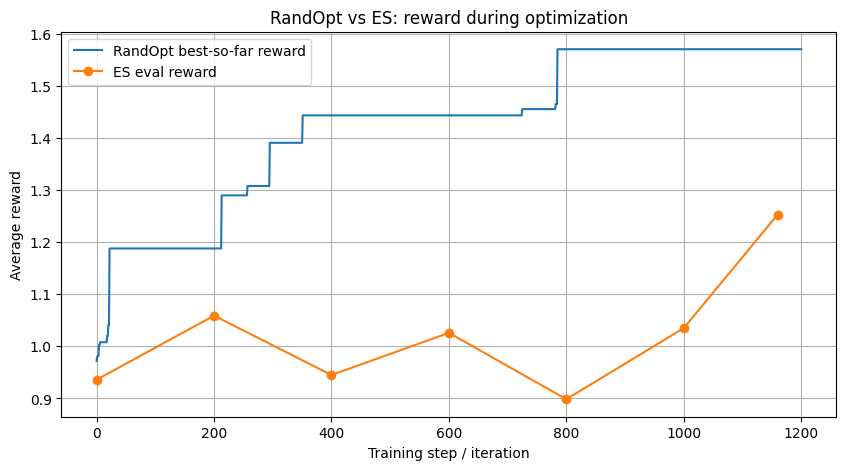

In [89]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 5))
plt.plot(rand_steps, rand_reward, label="RandOpt best-so-far reward")
es_x = [i * es_config["N"] for i in es_eval_iter]

plt.plot(es_x, es_eval_reward, marker="o", label="ES eval reward")
plt.xlabel("Training step / iteration")
plt.ylabel("Average reward")
plt.title("RandOpt vs ES: reward during optimization")
plt.legend()
plt.grid(True)
plt.show()

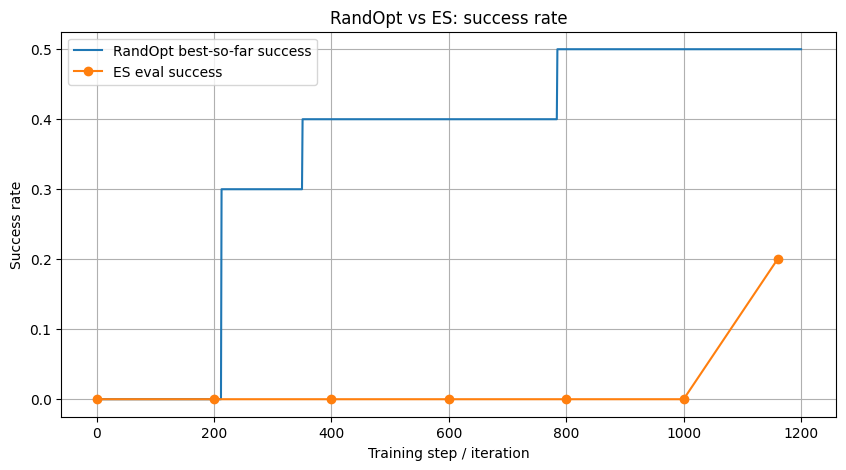

In [90]:
plt.figure(figsize=(10, 5))
plt.plot(rand_steps, rand_success, label="RandOpt best-so-far success")
es_x = [i * es_config["N"] for i in es_eval_iter]

plt.plot(es_x, es_eval_success, marker="o", label="ES eval success")
plt.xlabel("Training step / iteration")
plt.ylabel("Success rate")
plt.title("RandOpt vs ES: success rate")
plt.legend()
plt.grid(True)
plt.show()

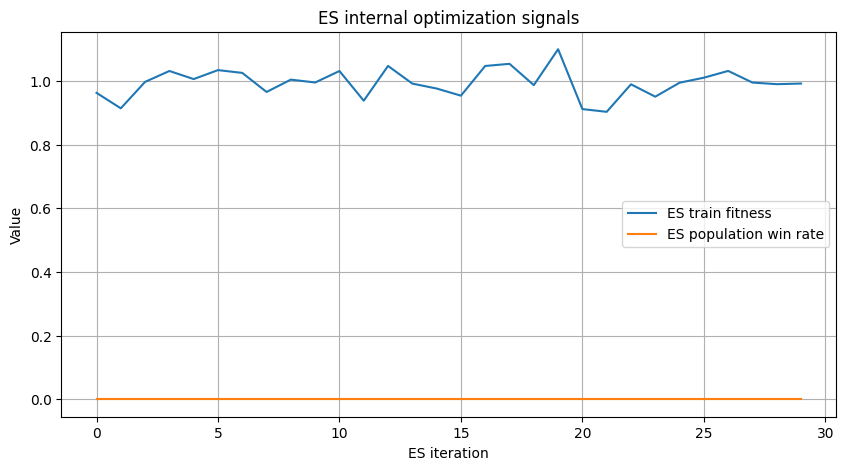

In [91]:
plt.figure(figsize=(10, 5))
plt.plot(es_train_iter, es_train_fitness, label="ES train fitness")
plt.plot(es_train_iter, es_train_win, label="ES population win rate")
plt.xlabel("ES iteration")
plt.ylabel("Value")
plt.title("ES internal optimization signals")
plt.legend()
plt.grid(True)
plt.show()

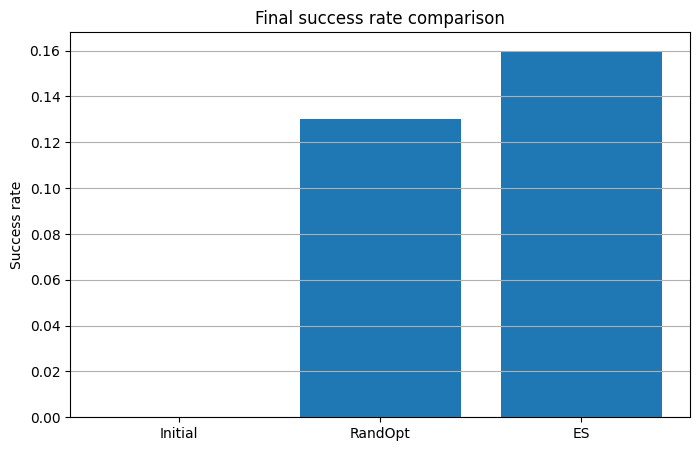

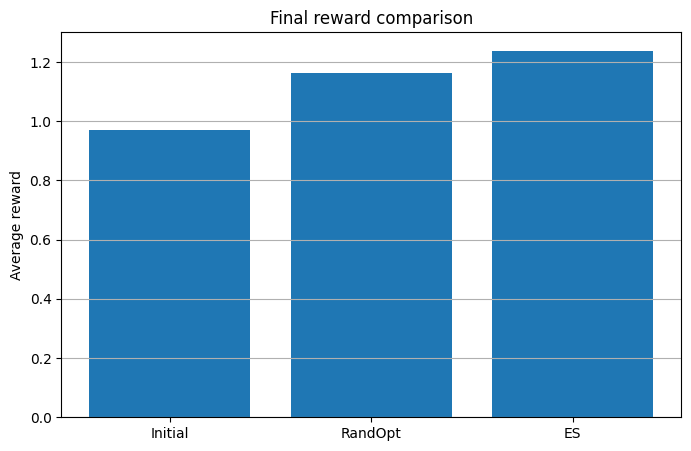

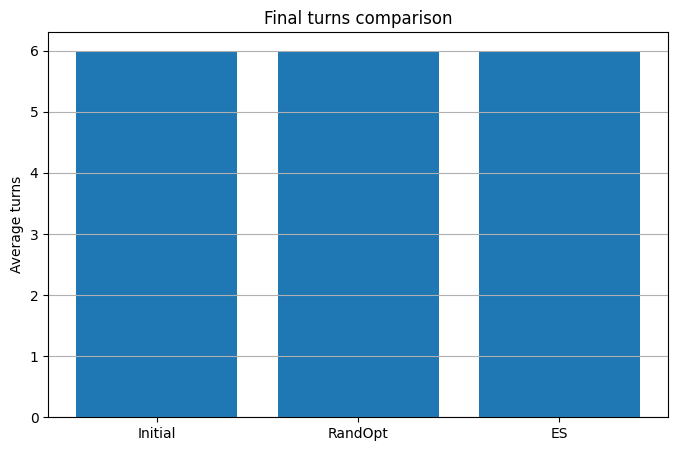

In [92]:
methods = ["Initial", "RandOpt", "ES"]
success_vals = [
    final_init["success_rate"],
    final_randopt["success_rate"],
    final_es["success_rate"],
]
reward_vals = [
    final_init["avg_reward"],
    final_randopt["avg_reward"],
    final_es["avg_reward"],
]
turn_vals = [
    final_init["avg_turns"],
    final_randopt["avg_turns"],
    final_es["avg_turns"],
]

plt.figure(figsize=(8, 5))
plt.bar(methods, success_vals)
plt.ylabel("Success rate")
plt.title("Final success rate comparison")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(methods, reward_vals)
plt.ylabel("Average reward")
plt.title("Final reward comparison")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(methods, turn_vals)
plt.ylabel("Average turns")
plt.title("Final turns comparison")
plt.grid(True, axis="y")
plt.show()